# Random Forest Wine Quality Model

This notebook uses the preprocessed CSV/data files created in `Preprocessing/winequiality_tuning_dataset.ipynb`.

This program:

1. Loads train and test csv.
2. Separates attributes and labels.
3. Imports random forest model.
4. Trains the model.
5. Plots train vs validation behavior (Accuracy).
6. Makes predictions for test.
7. Calculates metrics and show them on classification report.
8. Plots confusion Matrix.


## Imports

In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

import sys
import os

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load dataset

In [2]:
# Use the files generated in the Preprocessing notebook.
# If your files are named differently, only change these paths.

train_df = pd.read_csv("../../Dataset/train/preprocessed_train.csv")
test_df = pd.read_csv("../../Dataset/test/preprocessed_test.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

train_df.head()

Train shape: (3918, 12)
Test shape: (980, 12)


,alcohol,density,residual sugar,total sulfur dioxide,free sulfur dioxide,chlorides,citric acid,fixed acidity,pH,sulphates,volatile acidity,quality
0,0.811436,-1.015152,-0.396463,0.273654,0.090254,-0.876675,-0.777631,-1.476971,0.727373,-1.572934,-0.676949,7
1,1.954627,-1.633570,-0.945154,-0.762947,0.265528,-0.502390,-0.199185,-0.773832,0.465637,-0.870325,0.225769,7
2,-0.903350,0.248282,-0.376867,0.839073,1.492444,9.088661,-0.116550,-0.539453,-0.450439,-0.079891,-0.075137,5
3,0.893092,-1.477303,-1.023539,-0.998539,-0.201869,-0.455604,0.048721,-0.656643,-0.843043,2.203587,-0.576647,6
4,1.056405,-1.181394,-0.435656,-0.904302,0.090254,-0.783104,-1.438712,-1.828540,0.727373,-1.133804,0.225769,8


## 2. Separate attributes and labels


In [4]:
X_train = train_df.drop("quality", axis=1).astype("float32")
y_train = train_df["quality"].astype("int")

X_test = test_df.drop("quality", axis=1).astype("float32")
y_test = test_df["quality"].astype("int")

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts().sort_index())

print("\nTest class distribution:")
print(y_test.value_counts().sort_index())

print("\nUnique quality scores in training set:", y_train.unique())
print(y_train.value_counts().sort_index())

print(X_train.describe())
print(X_train.mean())
print(X_train.std())


X_train: (3918, 11)
y_train: (3918,)
X_test: (980, 11)
y_test: (980,)

Training class distribution:
quality
3      16
4     130
5    1166
6    1758
7     704
8     140
9       4
Name: count, dtype: int64

Test class distribution:
quality
3      4
4     33
5    291
6    440
7    176
8     35
9      1
Name: count, dtype: int64

Unique quality scores in training set: [7 5 6 8 4 3 9]
quality
3      16
4     130
5    1166
6    1758
7     704
8     140
9       4
Name: count, dtype: int64
            alcohol       density  residual sugar  total sulfur dioxide  \
count  3.918000e+03  3.918000e+03    3.918000e+03          3.918000e+03   
mean   2.434084e-09  4.868169e-09    1.168361e-08         -9.736338e-10   
std    1.000128e+00  1.000128e+00    1.000128e+00          1.000128e+00   
min   -2.046541e+00 -2.308510e+00   -1.141115e+00         -3.048182e+00   
25%   -8.216940e-01 -7.624654e-01   -9.255581e-01         -6.922700e-01   
50%   -8.678555e-02 -9.085019e-02   -2.396946e-01         -1.03

## 3. Import Random Forest model

In [5]:
sys.path.append(os.path.abspath("../../"))

from models.random_forest_model import create_model 

rf_model = create_model()

print(rf_model.get_params())


{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


In [6]:
rf_model.fit(X_train, y_train)

print("Número de árboles:", len(rf_model.estimators_))

Número de árboles: 100


## 4. Train model

In [7]:
rf_model.fit(X_train, y_train)

y_test_pred = rf_model.predict(X_test)


rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

## 5. Train vs Validation behavior plots (accuracy)

Unlike neural networks, Random Forest models do not learn through epochs or gradient descent. Instead, the model is built by generating multiple decision trees and combining their predictions. Because of this, the behavior is analyzed using the number of trees in the forest rather than epochs.

A traditional loss curve is not included because Random Forest does not optimize a loss function through gradient descent. Instead, each decision tree is constructed by minimizing node impurity using criteria such as Gini Impurity. Therefore, accuracy is a more appropriate metric for analyzing the fitting behavior of the model.

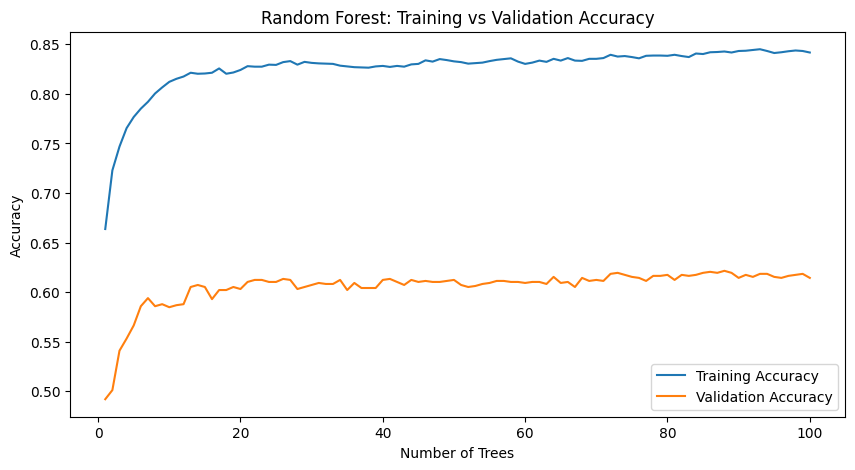

In [8]:
train_acc = []
val_acc = []

for n in range(1, 101):

    rf = RandomForestClassifier(
        n_estimators=n,
        max_depth=10,
        random_state=42
    )

    rf.fit(X_train, y_train)

    train_acc.append(
        accuracy_score(
            y_train,
            rf.predict(X_train)
        )
    )

    val_acc.append(
        accuracy_score(
            y_test,
            rf.predict(X_test)
        )
    )

plt.figure(figsize=(10,5))

plt.plot(
    range(1,101),
    train_acc,
    label="Training Accuracy"
)

plt.plot(
    range(1,101),
    val_acc,
    label="Validation Accuracy"
)

plt.title(
    "Random Forest: Training vs Validation Accuracy"
)

plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

## 6. Predictions

In [9]:
# Predictions
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

## 7. Metrics calculation and classification report.

### Metrics function

In [10]:
# Function to evaluate results

def evaluate_model(y_true, y_pred, dataset_name):
    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    print(f"{dataset_name} Results")
    print("---------------------")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

### Results

In [11]:
evaluate_model(y_train, y_train_pred, "Training")
print()
evaluate_model(y_test, y_test_pred, "Test")

Training Results
---------------------
Accuracy : 0.8418
Precision: 0.8558
Recall   : 0.8418
F1 Score : 0.8367

Test Results
---------------------
Accuracy : 0.6143
Precision: 0.6254
Recall   : 0.6143
F1 Score : 0.5934


### Classification report

In [12]:
print(classification_report(y_test, y_test_pred, zero_division=0))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.43      0.09      0.15        33
           5       0.67      0.58      0.62       291
           6       0.58      0.81      0.68       440
           7       0.64      0.37      0.47       176
           8       1.00      0.29      0.44        35
           9       0.00      0.00      0.00         1

    accuracy                           0.61       980
   macro avg       0.47      0.30      0.34       980
weighted avg       0.63      0.61      0.59       980



## 8. Confusion matrix

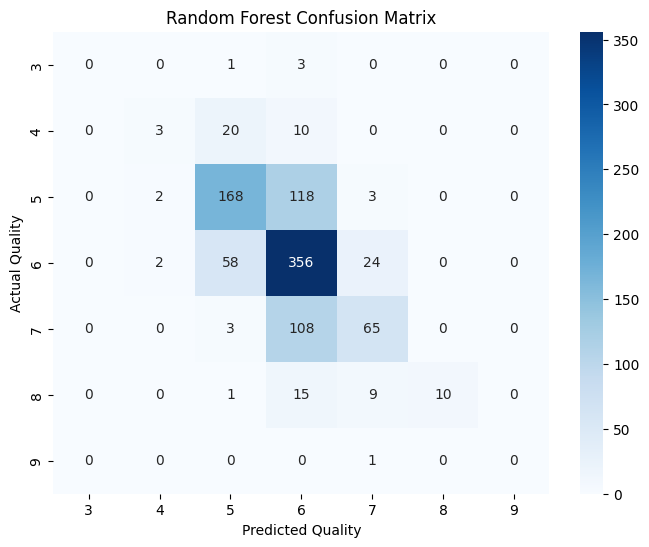

In [13]:
labels = sorted(
    set(y_train.unique()).union(
        set(y_test.unique())
    )
)

cm = confusion_matrix(
    y_test,
    y_test_pred,
    labels=labels
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Quality")
plt.ylabel("Actual Quality")

plt.show()